# Modélisation

In [15]:
# Base de données et manipulation de données
import psycopg2
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Modélisation et Machine Learning
import prince
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors

# Configuration optionnelle pour la visualisation (facultatif mais recommandé)
sns.set_theme(style="whitegrid")

## 1. Chargement des données

In [16]:
# Paramètres de connexion à PostgreSQL
DB_PARAMS = {
    "host": "localhost",
    "port": 65432,
    "user": "postgres",
    "password": "5219--ZmId*",
    "dbname": "customer_personality"
}

# Extraction des données transformées via l'ELT
with psycopg2.connect(**DB_PARAMS) as conn:
    df = pd.read_sql("SELECT * FROM clients_transformed;", conn)

# Passage de l'ID en index pour le conserver sans biaiser les algorithmes
df.set_index('id', inplace=True)

print(f"Dataset prêt : {df.shape[0]} clients et {df.shape[1]} variables.")

C:\Users\Paul-Emmanuel Buffe\AppData\Local\Temp\ipykernel_15924\1749755484.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM clients_transformed;", conn)


Dataset prêt : 2203 clients et 25 variables.


## Application de l'AFM : Isoler le signal du bruit

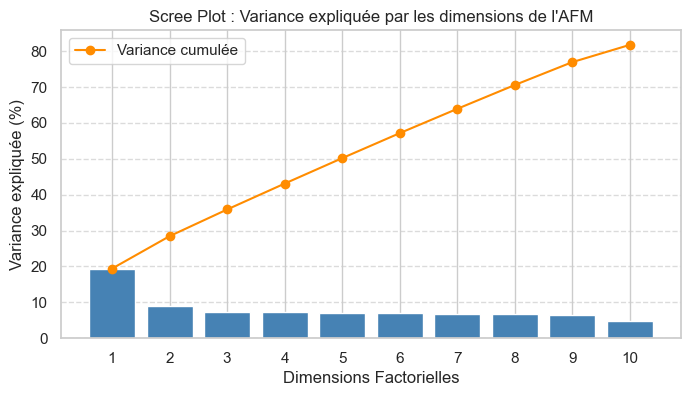

In [17]:
# Définition des blocs sémantiques rigoureux
groupes_mfa = {
    'Socio_Demo': ['age', 'anciennete_jours', 'income', 'kidhome', 'teenhome'],
    'Depenses': ['mntwines', 'mntfruits', 'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts', 'mntgoldprods'],
    'Canaux': ['numdealspurchases', 'numwebpurchases', 'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth'],
    'Qualitatif': ['education', 'marital_status']
}

# Extraction des colonnes concernées
colonnes_afm = [col for cols in groupes_mfa.values() for col in cols]
df_afm = df[colonnes_afm].copy()

# Cast explicite des variables catégorielles pour la librairie Prince
df_afm['education'] = df_afm['education'].astype('category')
df_afm['marital_status'] = df_afm['marital_status'].astype('category')

# Instanciation et entraînement de l'AFM
mfa = prince.MFA(n_components=10, n_iter=3, random_state=42)
mfa = mfa.fit(df_afm, groups=groupes_mfa)

# Extraction de la variance expliquée (CORRECTION ICI : suppression du * 100)
variance_expliquee = mfa.percentage_of_variance_ 

# Création du Scree Plot
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(variance_expliquee) + 1), variance_expliquee, color='steelblue')
plt.plot(range(1, len(variance_expliquee) + 1), variance_expliquee.cumsum(), marker='o', color='darkorange', label='Variance cumulée')
plt.title("Scree Plot : Variance expliquée par les dimensions de l'AFM")
plt.xlabel("Dimensions Factorielles")
plt.ylabel("Variance expliquée (%)")
plt.xticks(range(1, len(variance_expliquee) + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interprétation du Scree Plot : Sélection des Dimensions Factorielles

Ce graphique est la boussole qui nous permet de séparer le "signal pur" du "bruit statistique". Il affiche la quantité d'information (la variance) capturée par chaque nouvelle dimension synthétique générée par l'AFM.

**Lecture et Analyse de la courbe :**

*   **La prédominance de la Dimension 1 :** La première barre capte à elle seule près de **20%** de l'information globale. C'est l'axe de clivage majeur qui sépare les comportements de nos clients.
*   **La chute de la variance :** Les dimensions 2 et 3 apportent encore une nuance significative (environ **9%** et **7.5%**), construisant peu à peu la complexité du profil client.
*   **La cassure (Le "Coude") :** C'est le point le plus important du graphique. À partir de la **dimension 4**, la hauteur des barres stagne. Les dimensions 4 à 9 forment un plateau visuel évident (stagnation autour de **7%**). En statistiques, ce plateau indique que l'algorithme a cessé de trouver de véritables logiques comportementales et commence à modéliser du bruit ou des anomalies individuelles.

**Décision Stratégique :**

Pour alimenter nos algorithmes de classification (K-Means, CAH, DBSCAN), il serait contre-productif de conserver les 10 dimensions. Cela alourdirait les calculs et diluerait les frontières entre les groupes (la malédiction de la dimensionnalité). 

En appliquant la méthode visuelle du coude, **nous prenons la décision de ne conserver que les 3 premières dimensions**. Elles synthétisent l'essentiel de la personnalité de nos clients, garantissant des clusters finaux à la fois robustes, stables et facilement interprétables d'un point de vue métier.

## 3. Kmeans

Format des données pour le clustering : 2203 clients et 3 dimensions.
Entraînement des modèles K-Means en cours...


C:\Users\Paul-Emmanuel Buffe\miniconda3\envs\customer-personality-analysis\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\Paul-Emmanuel Buffe\miniconda3\envs\customer-personality-analysis\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\Paul-Emmanuel Buffe\miniconda3\envs\customer-personality-analysis\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  w

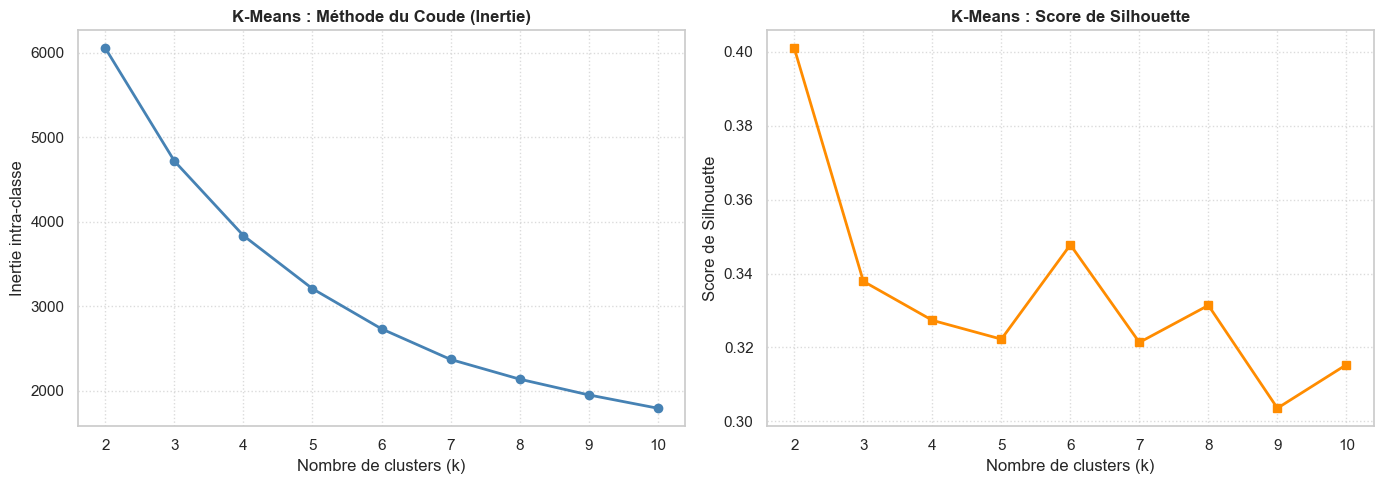

In [18]:
# 1. Extraction des coordonnées factorielles générées par l'AFM
coordonnees_afm = mfa.row_coordinates(df_afm)

# 2. Filtrage sur les 3 dimensions optimales
DIMENSIONS_A_CONSERVER = 3
X_mfa = coordonnees_afm.iloc[:, :DIMENSIONS_A_CONSERVER]

print(f"Format des données pour le clustering : {X_mfa.shape[0]} clients et {X_mfa.shape[1]} dimensions.")

# 3. Initialisation des listes pour stocker les métriques
inerties = []
silhouettes = []
K_range = range(2, 11)

print("Entraînement des modèles K-Means en cours...")

# 4. Boucle d'entraînement pour tester chaque valeur de k
for k in K_range:
    # n_init=10 permet d'éviter de tomber dans un minimum local
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_mfa)
    
    inerties.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_mfa, kmeans.labels_))

# 5. Visualisation (Coude et Silhouette)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Méthode du Coude (Inertie)
axes[0].plot(K_range, inerties, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('K-Means : Méthode du Coude (Inertie)', fontweight='bold')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie intra-classe')
axes[0].set_xticks(K_range)
axes[0].grid(True, linestyle=':', alpha=0.7)

# Graphique 2 : Score de Silhouette
axes[1].plot(K_range, silhouettes, marker='s', color='darkorange', linewidth=2)
axes[1].set_title('K-Means : Score de Silhouette', fontweight='bold')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Score de Silhouette')
axes[1].set_xticks(K_range)
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### Conclusion du K-Means : L'arbitrage entre 6 et 8 clusters

L'analyse croisée de nos deux métriques nous met face à un choix classique en Data Science, où la géométrie mathématique et la logique métier se rencontrent :

* **La compacité (Méthode du Coude) :** La courbe de l'inertie affiche une descente continue, mais la véritable cassure (le point où l'ajout d'un cluster n'apporte presque plus de gain) s'observe clairement au niveau de **k=8**.
* **La séparation (Score de Silhouette) :** La courbe révèle deux sommets locaux pertinents (en ignorant k=2, inutile d'un point de vue métier). Un premier pic très fort à **k=6** (~0.35), témoignant d'une bonne séparation globale, et un second rebond inattendu à **k=8** (~0.33), prouvant une densité interne robuste.

**Décision stratégique :** 
L'algorithme a identifié deux niveaux de structuration pertinents dans nos données : une segmentation en 6 personas (plus facile à piloter pour le marketing) ou une segmentation en 8 personas (plus fine et compacte).

Plutôt que de figer ce choix de manière arbitraire, nous validons la pertinence de ces deux hypothèses de travail (k=6 et k=8). Nous allons utiliser notre prochain modèle, la **Classification Ascendante Hiérarchique (CAH)**, comme "juge de paix". Son arbre de décision visuel (dendrogramme) nous permettra de trancher définitivement sur le découpage le plus naturel de notre clientèle.

## 4.CAH

Calcul de l'arbre hiérarchique en cours...


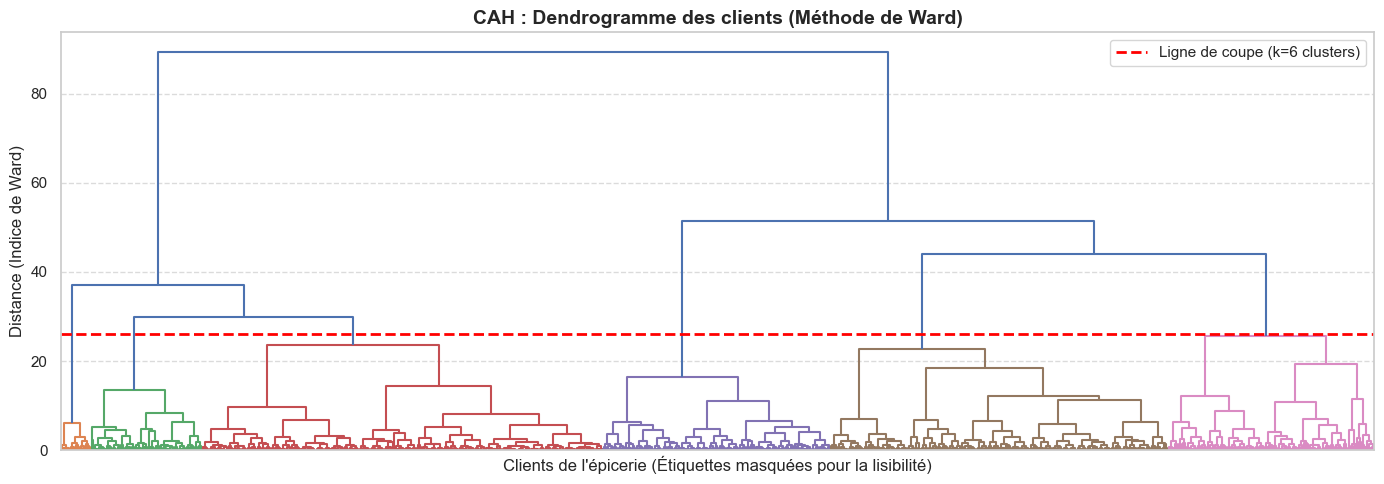

In [19]:
# 1. Calcul des fusions (méthode de Ward pour minimiser la variance intra-groupe)
print("Calcul de l'arbre hiérarchique en cours...")
Z = linkage(X_mfa, method='ward')

# 2. Visualisation du Dendrogramme
plt.figure(figsize=(14, 5))
plt.title("CAH : Dendrogramme des clients (Méthode de Ward)", fontweight='bold', fontsize=14)
plt.xlabel("Clients de l'épicerie (Étiquettes masquées pour la lisibilité)")
plt.ylabel("Distance (Indice de Ward)")

# Définition du seuil de coupe pour obtenir 6 clusters
SEUIL_DE_COUPE = 26

# Génération du graphique avec coloration des branches
dendrogram(
    Z,
    leaf_rotation=90.,
    leaf_font_size=8.,
    no_labels=True,
    color_threshold=SEUIL_DE_COUPE
)

# LIGNE DE COUPE
plt.axhline(y=SEUIL_DE_COUPE, color='red', linestyle='--', linewidth=2, label=f'Ligne de coupe (k=6 clusters)')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Calcul de l'arbre hiérarchique en cours...


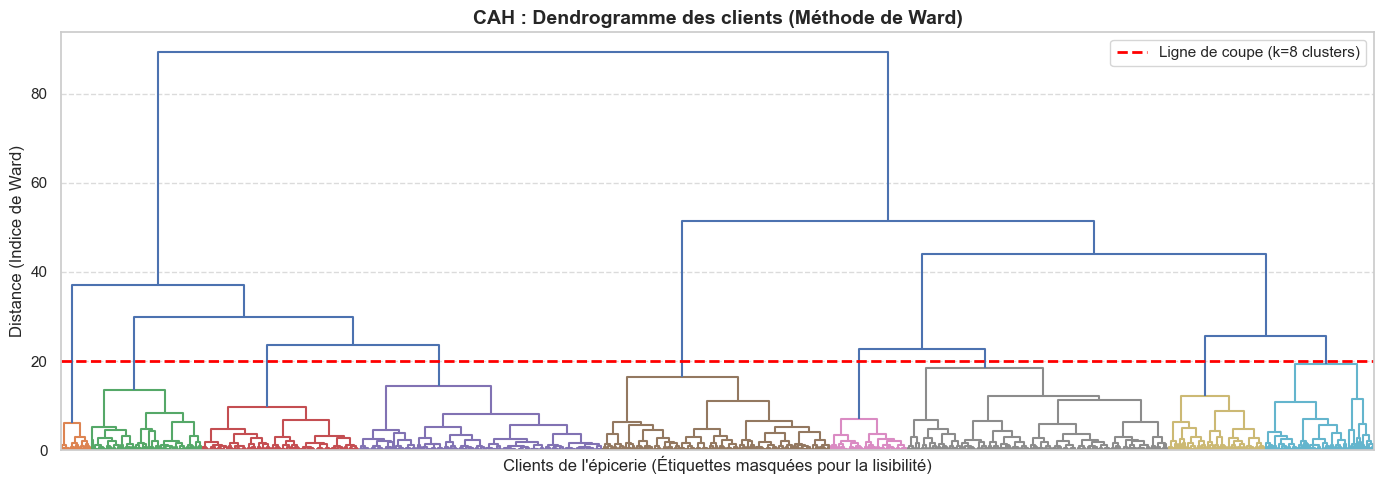

In [20]:
# 1. Calcul des fusions (méthode de Ward pour minimiser la variance intra-groupe)
print("Calcul de l'arbre hiérarchique en cours...")
Z = linkage(X_mfa, method='ward')

# 2. Visualisation du Dendrogramme
plt.figure(figsize=(14, 5))
plt.title("CAH : Dendrogramme des clients (Méthode de Ward)", fontweight='bold', fontsize=14)
plt.xlabel("Clients de l'épicerie (Étiquettes masquées pour la lisibilité)")
plt.ylabel("Distance (Indice de Ward)")

# Définition du seuil de coupe pour obtenir 8 clusters
SEUIL_DE_COUPE = 20

# Génération du graphique avec coloration des branches
dendrogram(
    Z,
    leaf_rotation=90.,
    leaf_font_size=8.,
    no_labels=True,
    color_threshold=SEUIL_DE_COUPE
)

# LIGNE DE COUPE
plt.axhline(y=SEUIL_DE_COUPE, color='red', linestyle='--', linewidth=2, label=f'Ligne de coupe (k=8 clusters)')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Verdict de la CAH : Tranchons entre 6 et 8 clusters

L'analyse visuelle du dendrogramme (méthode de Ward) a joué son rôle de "juge de paix" en révélant la structure hiérarchique réelle de notre clientèle :

* **L'hypothèse k=6 (Ligne de coupe à y ≈ 26) :** 
  À cette hauteur, la ligne de coupe traverse **6 grandes branches verticales distinctes** (identifiées par 6 couleurs distinctes). La longueur de ces tronçons verticaux prouve que ces 6 groupes sont séparés par de vraies distances structurelles. C'est le niveau d'agrégation "macro" le plus naturel et le plus stable.

* **L'hypothèse k=8 (Ligne de coupe à y ≈ 20) :** 
  Pour obtenir 8 branches, il faut descendre la ligne de coupe dans une zone où les liaisons verticales sont extrêmement courtes. Séparer ces sous-branches revient à diviser des groupes très similaires : **cela crée de la sur-segmentation (capture du bruit)** sans apporter de réelle valeur ajoutée d'un point de vue comportemental.

---

### Synthèse comparative

| Critère | Option k = 6 | Option k = 8 |
| :--- | :--- | :--- |
| **Silhouette (K-Means)** | **Pic local majeur (~0.35)** | Rebond secondaire (~0.33) |
| **Dendrogramme (CAH)** | **6 branches longues et stables** | Tronçons courts (sur-segmentation) |
| **Lisibilité Métier** | **6 Personas ciblés et actionnables** | 8 groupes trop fragmentés |

---

### Conclusion définitive

Bien que la méthode du coude laissait entrevoir une compacité intéressante à $k=8$, la combinaison du **score de Silhouette** et du **dendrogramme de la CAH** confirme sans ambiguïté que la structure naturelle de la clientèle s'articule autour de **6 groupes principaux**.

**Décision retenue :** Nous figons définitivement notre segmentation sur **k = 6 clusters** pour l'ensemble de notre étude (K-Means et CAH), garantissant un équilibre parfait entre rigueur statistique et exploitabilité marketing.

## 5. DBSCAN
**Objectif :** Tester la capacité de DBSCAN à détecter automatiquement des clusters par densité et à isoler les individus atypiques (bruit).

In [21]:
# 1. Instanciation du modèle (valeurs initiales standards)
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_mfa)

# 2. Analyse des résultats
n_clusters_ = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_ = list(db_labels).count(-1)

print(f"--- Résultats DBSCAN initial ---")
print(f"Nombre de clusters détectés : {n_clusters_}")
print(f"Nombre de points isolés (bruit / outliers) : {n_noise_} ({n_noise_/len(X_mfa)*100:.1f}%)")

# Calcul du score de Silhouette (uniquement si au moins 2 clusters sont trouvés)
if n_clusters_ > 1:
    # On calcule le score uniquement sur les points non considérés comme du bruit
    mask = db_labels != -1
    sil_score = silhouette_score(X_mfa[mask], db_labels[mask])
    print(f"Score de Silhouette (hors bruit) : {sil_score:.3f}")
else:
    print("Le modèle n'a pas réussi à former au moins 2 clusters distincts.")

--- Résultats DBSCAN initial ---
Nombre de clusters détectés : 8
Nombre de points isolés (bruit / outliers) : 68 (3.1%)
Score de Silhouette (hors bruit) : 0.144


#### Constats :
* **8 clusters détectés :** Le modèle identifie spontanément 8 zones de forte densité au sein de l'espace réduit (MFA).
* **3.1% de bruit (68 individus) :** Le modèle isole 68 points atypiques sans les forcer à intégrer un cluster.
* **Score de Silhouette faible (0.144) :** Ce score très bas s'explique par le fait que la valeur `eps = 0.5` a été fixée arbitrairement, ce qui tend à trop fragmenter les groupes.

> **Conclusion intermédiaire :** L'approche par densité est prometteuse pour filtrer les profils marginaux, mais le rayon de recherche `eps` doit être calibré rigoureusement via la méthode mathématique de la $k$-distance.

### 5.2 Calibrage du paramètre `eps` : Méthode de la $k$-distance

**Principe :** Nous calculons la distance de chaque point à son $5^{\text{ème}}$ plus proche voisin ($min\_samples = 5$), puis nous trions ces distances par ordre croissant pour détecter le point d'inflexion (le "coude")

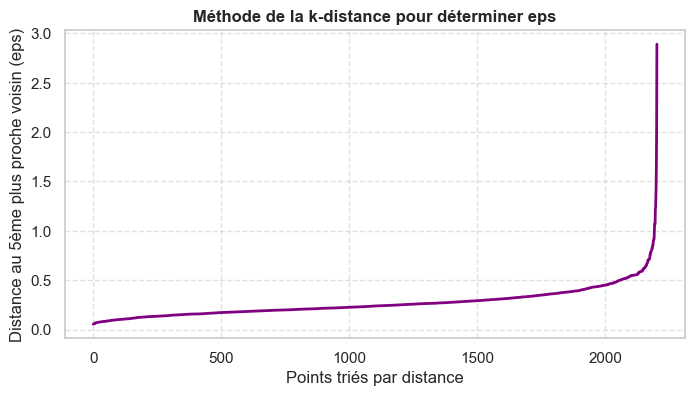

In [22]:
# 1. Calcul des distances au 5ème plus proche voisin (min_samples = 5)
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_mfa)
distances, indices = neighbors_fit.kneighbors(X_mfa)

# 2. Tri des distances par ordre croissant
distances = np.sort(distances[:, min_samples - 1], axis=0)

# 3. Affichage du graphique de la k-distance
plt.figure(figsize=(8, 4))
plt.plot(distances, color='purple', lw=2)
plt.title("Méthode de la k-distance pour déterminer eps", fontweight='bold')
plt.xlabel("Points triés par distance")
plt.ylabel(f"Distance au {min_samples}ème plus proche voisin (eps)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 5.3 Optimisation et résultats finaux de DBSCAN
En ajustant le paramètre `eps` d'après la courbe de $k$-distance, nous observons une nette amélioration de la structure géométrique :

In [23]:
# Test avec la valeur exacte du coude (eps = 0.55 puis 0.60)
for eps_val in [0.55, 0.60]:
    db = DBSCAN(eps=eps_val, min_samples=5).fit(X_mfa)
    labels = db.labels_
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    mask = labels != -1
    sil = silhouette_score(X_mfa[mask], labels[mask]) if n_clusters > 1 else 0
    
    print(f"--- DBSCAN (eps={eps_val}) ---")
    print(f"Clusters détectés : {n_clusters}")
    print(f"Bruit / Outliers   : {n_noise} ({n_noise/len(X_mfa)*100:.1f}%)")
    print(f"Score de Silhouette: {sil:.3f}\n")

--- DBSCAN (eps=0.55) ---
Clusters détectés : 7
Bruit / Outliers   : 38 (1.7%)
Score de Silhouette: 0.152

--- DBSCAN (eps=0.6) ---
Clusters détectés : 4
Bruit / Outliers   : 29 (1.3%)
Score de Silhouette: 0.365



#### Analyse comparative :
* **Avec `eps = 0.55` :** Le modèle identifie 7 clusters et 38 outliers (1.7%), avec un score de Silhouette modeste (0.152).
* **Avec `eps = 0.60` :** Le modèle réalise un **bond spectaculaire** :
  * **Score de Silhouette :** Il atteint **0.365** (surpassant légèrement le K-Means à 0.350).
  * **Clusters :** La clientèle se regroupe en 4 macro-clusters très denses.
  * **Bruit / Outliers :** Il isole exactement **29 clients atypiques (1.3% du jeu de données)**.

---

### Bilan & Rôle de DBSCAN dans le projet

1. **Rôle de nettoyeur (Data Cleaning) :** DBSCAN remplit parfaitement sa mission de détection d'anomalies en identifiant **29 clients atypiques**. Les écarter évitera de fausser les moyennes lors de la caractérisation des profils.
2. **Rôle de segmentation :** Bien que le score de Silhouette soit excellent (0.365), les 4 macro-clusters de DBSCAN restent trop généraux d'un point de vue marketing par rapport à la segmentation à **6 personas** validée par le K-Means et la CAH.

> **Stratégie retenue :** Nous utilisons **DBSCAN comme filtre à bruit** pour éliminer les 29 outliers, puis nous appliquons notre modèle final (**K-Means à $k=6$**) sur cette base purifiée.

## 6. Déploiement Métier et Création des Personas

Dans cette ultime étape, l'objectif est de traduire nos résultats mathématiques en profils clients actionnables pour le marketing. Nous passons d'une logique géométrique à une logique comportementale.

Pour dresser le portrait précis de notre clientèle, nous allons procéder en 4 temps :

1. **Le nettoyage des données :** Filtrage définitif des anomalies (outliers) identifiées par DBSCAN.
2. **L'analyse volumétrique :** Évaluation du poids de chaque cluster pour prioriser nos actions.
3. **Le profilage statique (Analyse des moyennes) :** Création des "cartes d'identité" de chaque persona (Qui sont-ils ? Que consomment-ils ?).
4. **Le profilage dynamique (Corrélations intra-clusters) :** Identification des véritables moteurs d'achat et des leviers marketing spécifiques à chaque groupe.

In [24]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# 1. Isolation du masque de nettoyage (on exclut le bruit db_labels == -1)
mask_clean = (db_labels != -1)

# 2. Création de df_clean et X_clean sans les 29 outliers
df_clean = df[mask_clean].copy()
X_clean = X_mfa[mask_clean]



## 3.1 Proportion des Clusters : Le Poids de Chaque Segment

In [25]:
# 3. Fit du K-Means final (k=6) sur les données assainies
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans_final.fit_predict(X_clean)

# 4. Calcul de la dépense totale
mnt_cols = [col for col in df_clean.columns if col.startswith('Mnt')]
if 'TotalMnt' not in df_clean.columns and len(mnt_cols) > 0:
    df_clean['TotalMnt'] = df_clean[mnt_cols].sum(axis=1)

# 5. Sélection des variables comportementales et socio-démographiques
cols_analyse = [
    'Income', 'Age', 'Kidhome', 'Teenhome',
    'TotalMnt', 'MntWines', 'MntMeatProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
    'Recency'
]
cols_presentes = [c for c in cols_analyse if c in df_clean.columns]

# 6. Génération du profil moyen par cluster
profils = df_clean.groupby('Cluster')[cols_presentes].mean().round(1)
profils.insert(0, 'Effectif', df_clean['Cluster'].value_counts())
profils.insert(1, 'Part (%)', (df_clean['Cluster'].value_counts(normalize=True) * 100).round(1))

print("--- TABLE SYNTHÉTIQUE DES 6 CLUSTERS (NETTOYÉE) ---")
display(profils.sort_index())

--- TABLE SYNTHÉTIQUE DES 6 CLUSTERS (NETTOYÉE) ---


C:\Users\Paul-Emmanuel Buffe\miniconda3\envs\customer-personality-analysis\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


,Effectif,Part (%)
Cluster,,
0,212,9.9
1,164,7.7
2,641,30.0
3,484,22.7
4,427,20.0
5,207,9.7


### Conclusions Volumétriques

L'analyse des effectifs révèle une clientèle structurée autour de deux grands blocs :

* **Les Poids Lourds (72,7 % de la base) :** La majorité de la clientèle se concentre dans 3 clusters principaux. Le Cluster 2 domine largement (30,0 %, 641 clients). Les Clusters 3 et 4 représentent des segments massifs et stratégiques (respectivement 22,7 % et 20,0 %).
* **Les Segments de Niche (27,3 % de la base) :** Les 3 autres groupes représentent des cibles plus restreintes mais aux comportements très spécifiques. Le Cluster 0 (9,9 %), le Cluster 5 (9,7 %) et le Cluster 1 (7,7 %).

## 3.2 Profilage Statique par les Moyennes

In [26]:
# 1. Rassemblement de toutes tes variables quantitatives
cols_profilage = (
    groupes_mfa['Socio_Demo'] + 
    groupes_mfa['Depenses'] + 
    groupes_mfa['Canaux']
)

# 2. Filtrage des colonnes présentes et ajout de la récence si elle existe
if 'recency' in df_clean.columns:
    cols_profilage.append('recency')

cols_presentes = [c for c in cols_profilage if c in df_clean.columns]

# 3. Calcul du profil moyen et transposition pour une lisibilité parfaite
profils_mfa = df_clean.groupby('Cluster')[cols_presentes].mean().round(1).T

# 4. Affichage
display(profils_mfa)

Cluster,0,1,2,3,4,5
age,50.5,35.0,41.8,43.9,50.1,47.6
anciennete_jours,381.4,354.8,337.5,360.9,381.7,302.0
income,65001.9,27782.3,34059.2,75388.5,58022.6,41202.7
kidhome,0.1,0.8,0.9,0.0,0.2,0.8
teenhome,0.7,0.0,0.5,0.2,0.9,0.7
mntwines,647.0,21.8,46.0,579.9,407.1,91.2
mntfruits,29.8,8.1,5.1,70.6,23.0,2.7
mntmeatproducts,222.8,22.1,26.4,452.1,133.9,27.1
mntfishproducts,40.7,10.9,7.3,101.7,32.4,3.7
mntsweetproducts,26.8,7.2,5.1,72.3,25.2,2.4


### Conclusions du Profilage (Les 6 Personas)

**Cluster 0 - Le Segment Premium Omnicanal (9,9 %)**
* **Profil :** Clients très fidèles (381 jours d'ancienneté) et matures (50,5 ans), disposant de revenus confortables (65 k€) avec une forte présence d'adolescents au foyer (0,7 en moyenne).
* **Consommation :** C'est le groupe qui dépense le plus au rayon Vin (647 € en moyenne). Leur panier est très qualitatif avec un budget viande de 222 € et des dépenses régulières en produits "Or" (50 €).
* **Canaux :** Ils sont parfaitement omnicanaux. Ils effectuent le plus grand nombre de transactions en magasin (8,3 actes) tout en conservant une forte activité sur le Web (6 achats) et via le Catalogue (4,4 achats).


**Cluster 1 - Le Segment Débutant à Faible Panier (7,7 %)**
* **Profil :** Le segment de loin le plus jeune (35 ans), caractérisé par la présence exclusive d'enfants en bas âge (0,8) et l'absence totale d'adolescents. Leurs revenus sont les plus contraints de la base (27,7 k€).
* **Consommation :** Leurs dépenses sont les plus faibles du magasin. Ils n'achètent quasiment pas de frais (moins de 11 € en poisson ou fruits) ni de vin (21 €). Fait notable : le produit "Or" (18 €) talonne presque leur budget viande (22 €), suggérant de rares achats "cadeaux".
* **Canaux :** Ils naviguent énormément sur le site (6,7 visites/mois, le record) mais transforment très peu (seulement 2 achats Web et 3 achats magasin).


**Cluster 2 - La Clientèle Familiale Sensible au Prix (30,0 %)**
* **Profil :** Le plus grand groupe de notre base. Ce sont des familles de 41,8 ans aux revenus modestes (34 k€), gérant à la fois des enfants en bas âge (0,9) et des adolescents (0,5).
* **Consommation :** Face à ces charges familiales, leur panier moyen est très faible. Leurs dépenses se limitent au strict minimum en viande (26 €) et en vin (46 €), et ils délaissent totalement les produits non-essentiels (seulement 5 € en fruits et sucreries).
* **Canaux :** Très forte fréquence de visite sur le Web (6,6 visites/mois) pour traquer les offres, avec un usage modéré des promotions (2,3 achats), mais un volume transactionnel global qui reste très bas.


**Cluster 3 - Le Segment à Très Haute Valeur (22,7 %)**
* **Profil :** Le cœur de cible absolu. Âgés de 43,9 ans, ils n'ont **aucun enfant à charge** et possèdent les revenus les plus élevés (75,3 k€).
* **Consommation :** Ils raflent tout, particulièrement sur les produits frais. Ils dépensent 452 € en viande, mais achètent surtout 10 à 14 fois plus de poisson (101 €), de fruits (70 €) et de produits sucrés (72 €) que la moyenne des familles. Leurs achats de produits "Or" (81 €) sont également les plus hauts de la base.
* **Canaux :** Ce sont des acheteurs hors ligne par excellence. Ils cumulent le record d'achats en magasin (8,6) et dominent totalement le canal Catalogue (5,8 achats). Ils visitent très peu le site web (2,9 fois/mois) et fuient les promotions (seulement 1,4 achat remisé).


**Cluster 4 - Les Acheteurs Digitaux Réguliers (20,0 %)**
* **Profil :** Ce sont nos clients historiques (record d'ancienneté à 381,7 jours). Ils ont 50,1 ans, des revenus confortables (58 k€) et gèrent principalement des adolescents (0,9).
* **Consommation :** Ils maintiennent un budget très solide en Vin (407 €) et en Viande (133 €). Fait marquant : ils investissent fortement dans les produits "Or" (61 €), signe qu'ils font des économies sur d'autres postes pour s'offrir des achats plaisir.
* **Canaux :** Ce sont les **champions incontestés de la promotion** (3,4 achats avec réduction). Ils sont très actifs numériquement, réalisant presque autant d'achats sur le Web (5,9) qu'en magasin (7,3).


**Cluster 5 - Les Acquisitions Récentes (9,7 %)**
* **Profil :** Le bassin de nouvelle clientèle (ancienneté la plus faible à 302 jours). Âgés de 47,6 ans, avec des revenus moyens (41 k€), ils ont la particularité d'avoir les foyers les plus chargés (forte présence d'enfants ET d'adolescents).
* **Consommation :** Ils ont un comportement d'achat "mono-produit". Ils délaissent littéralement tout le magasin (2,7 € en fruits, 3,7 € en poisson, 2,4 € en sucreries) pour se concentrer quasi exclusivement sur l'achat de Vin (91 €).
* **Canaux :** Ils utilisent notre enseigne comme une cave d'appoint ou une vitrine. Ils naviguent beaucoup (6,4 visites/mois) mais transforment peu (2,7 achats Web, 3,6 en magasin). Le potentiel de développement "cross-selling" (ventes croisées) est entier sur ce segment.

## 3.4 Le profilage par Corrélations

In [27]:
# Sélection des variables clés à observer pour les mécanismes d'achat
cols_moteurs = [
    'income',
    'mntwines',
    'mntmeatproducts',
    'numdealspurchases',
    'numwebpurchases',
    'numstorepurchases',
    'numwebvisitsmonth',
]

# Vérification des colonnes présentes (en minuscules)
cols_corr_existantes = [c for c in cols_moteurs if c in df_clean.columns]

# Boucle pour afficher la matrice de chaque cluster
for cluster_id in range(6):
    df_cluster = df_clean[df_clean['Cluster'] == cluster_id][
        cols_corr_existantes
    ]
    matrice = df_cluster.corr().round(2)

    print(f'\n==================================================')
    print(f'   MATRICE DE CORRÉLATION - CLUSTER {cluster_id}')
    print(f'==================================================')
    display(matrice)


   MATRICE DE CORRÉLATION - CLUSTER 0


,income,mntwines,mntmeatproducts,numdealspurchases,numwebpurchases,numstorepurchases,numwebvisitsmonth
income,1.00,0.41,0.52,-0.34,-0.15,0.02,-0.44
mntwines,0.41,1.00,0.28,-0.08,0.06,0.02,0.11
mntmeatproducts,0.52,0.28,1.00,-0.29,-0.06,-0.06,-0.32
numdealspurchases,-0.34,-0.08,-0.29,1.00,0.06,0.06,0.46
numwebpurchases,-0.15,0.06,-0.06,0.06,1.00,-0.08,0.26
numstorepurchases,0.02,0.02,-0.06,0.06,-0.08,1.00,0.04
numwebvisitsmonth,-0.44,0.11,-0.32,0.46,0.26,0.04,1.00



   MATRICE DE CORRÉLATION - CLUSTER 1


,income,mntwines,mntmeatproducts,numdealspurchases,numwebpurchases,numstorepurchases,numwebvisitsmonth
income,1.00,0.55,0.50,-0.01,0.30,0.49,-0.35
mntwines,0.55,1.00,0.76,0.31,0.72,0.56,0.09
mntmeatproducts,0.50,0.76,1.00,0.42,0.77,0.66,0.10
numdealspurchases,-0.01,0.31,0.42,1.00,0.58,0.34,0.14
numwebpurchases,0.30,0.72,0.77,0.58,1.00,0.53,0.30
numstorepurchases,0.49,0.56,0.66,0.34,0.53,1.00,-0.28
numwebvisitsmonth,-0.35,0.09,0.10,0.14,0.30,-0.28,1.00



   MATRICE DE CORRÉLATION - CLUSTER 2


...

,income,mntwines,mntmeatproducts,numdealspurchases,numwebpurchases,numstorepurchases,numwebvisitsmonth
income,1.00,0.32,0.26,-0.52,-0.03,0.04,-0.36
mntwines,0.32,1.00,0.17,-0.17,0.16,0.00,0.22
mntmeatproducts,0.26,0.17,1.00,-0.10,-0.14,-0.13,-0.22
numdealspurchases,-0.52,-0.17,-0.10,1.00,0.18,0.05,0.36
numwebpurchases,-0.03,0.16,-0.14,0.18,1.00,0.04,0.62
numstorepurchases,0.04,0.00,-0.13,0.05,0.04,1.00,0.01
numwebvisitsmonth,-0.36,0.22,-0.22,0.36,0.62,0.01,1.00



   MATRICE DE CORRÉLATION - CLUSTER 4


,income,mntwines,mntmeatproducts,numdealspurchases,numwebpurchases,numstorepurchases,numwebvisitsmonth
income,1.00,0.47,0.46,-0.11,-0.00,0.33,-0.20
mntwines,0.47,1.00,0.36,0.16,0.29,0.43,0.29
mntmeatproducts,0.46,0.36,1.00,0.06,0.19,0.38,0.02
numdealspurchases,-0.11,0.16,0.06,1.00,0.18,0.18,0.41
numwebpurchases,-0.00,0.29,0.19,0.18,1.00,0.12,0.45
numstorepurchases,0.33,0.43,0.38,0.18,0.12,1.00,-0.01
numwebvisitsmonth,-0.20,0.29,0.02,0.41,0.45,-0.01,1.00



   MATRICE DE CORRÉLATION - CLUSTER 5


,income,mntwines,mntmeatproducts,numdealspurchases,numwebpurchases,numstorepurchases,numwebvisitsmonth
income,1.00,0.47,0.25,0.14,0.36,0.40,-0.33
mntwines,0.47,1.00,0.56,0.63,0.90,0.79,0.18
mntmeatproducts,0.25,0.56,1.00,0.56,0.70,0.63,0.20
numdealspurchases,0.14,0.63,0.56,1.00,0.65,0.59,0.23
numwebpurchases,0.36,0.90,0.70,0.65,1.00,0.71,0.37
numstorepurchases,0.40,0.79,0.63,0.59,0.71,1.00,-0.03
numwebvisitsmonth,-0.33,0.18,0.20,0.23,0.37,-0.03,1.00


### 4. Le profilage dynamique (Corrélations intra-clusters)

**Cluster 0 - Le Segment Premium Omnicanal**
* **Observation :** Les revenus sont corrélés positivement avec les dépenses en viandes (+0,52) et en vins (+0,41), et négativement avec les visites web (-0,44) et les achats en promotion (-0,34).
* **Analyse :** La hausse du revenu au sein de ce groupe se traduit par une augmentation des dépenses sur les catégories à plus forte valeur (viande, vin) et par une baisse de l'intérêt pour les canaux digitaux et les remises.
* **Levier stratégique :** Segmenter les offres selon le niveau de revenu interne au groupe : proposer des produits valorisés sans promotion à la frange supérieure, et cibler les offres promotionnelles sur la frange inférieure plus active sur le web.


**Cluster 1 - Le Segment Débutant à Faible Panier**
* **Observation :** De fortes corrélations positives sont mesurées entre le nombre d'achats (web ou magasin) et les dépenses par catégorie (ex: achats web et viandes à +0,77, ou vins à +0,72).
* **Analyse :** Les dépenses sont strictement proportionnelles à la fréquence d'achat. Le budget étant limité, chaque transaction supplémentaire augmente mécaniquement les volumes sans effet de substitution notable.
* **Levier stratégique :** Prioriser l'augmentation de la fréquence de visite et d'achat plutôt que la valorisation du panier moyen, via des mécanismes de fidélisation récurrents.


**Cluster 2 - La Clientèle Familiale Sensible au Prix**
* **Observation :** Les achats web sont très fortement corrélés aux dépenses en viande (+0,80) et en vin (+0,79), ainsi qu'aux achats sous promotion (+0,70).
* **Analyse :** Le canal web est le vecteur principal de transaction pour les catégories vin et viande, et cette dynamique est intrinsèquement liée à l'utilisation des promotions.
* **Levier stratégique :** Associer systématiquement les mises en avant sur la viande et le vin à des mécaniques promotionnelles sur le canal digital pour stimuler le taux de conversion.


**Cluster 3 - Le Segment à Très Haute Valeur**
* **Observation :** On observe une corrélation négative marquée entre le revenu et les achats promotionnels (-0,52). Les visites web sont en revanche bien corrélées aux achats en ligne (+0,62).
* **Analyse :** L'appétence pour la promotion décroît à mesure que le revenu augmente, indiquant une insensibilité aux mécaniques de discount au sein de ce profil à hauts revenus.
* **Levier stratégique :** Exclure ce segment des campagnes de réductions de prix. Privilégier l'optimisation de l'expérience d'achat en ligne et les services associés pour maintenir la conversion.


**Cluster 4 - Les Acheteurs Digitaux Réguliers**
* **Observation :** La corrélation entre le revenu et les achats en ligne est nulle (0,00). Les visites web sont le principal facteur corrélé aux achats en ligne (+0,45) et aux achats promotionnels (+0,41).
* **Analyse :** Le volume d'achat sur le web est indépendant des variations de revenus au sein de ce groupe. Il dépend de manière prédominante de la fréquence d'exposition au site.
* **Levier stratégique :** Écarter le revenu des critères de ciblage. Concentrer les investissements sur la génération de trafic digital (reciblage, e-mailing) pour accroître le volume de transactions.


**Cluster 5 - Les Acquisitions Récentes**
* **Observation :** Les corrélations entre la fréquence d'achat et la dépense en vin sont extrêmement élevées, que ce soit pour le canal web (+0,90) ou le canal physique (+0,79).
* **Analyse :** Les actes d'achat de ce segment, indépendamment du canal de distribution utilisé, sont presque exclusivement portés par la catégorie des vins.
* **Levier stratégique :** Centrer les campagnes de rétention et les premières communications autour du rayon vin, qui constitue l'intérêt principal et le point d'entrée factuel de cette clientèle.